# PyMMM Pipeline: ND2 → Zarr

This notebook demonstrates the full PyMMM pipeline:
1. Load an ND2 file lazily
2. Register (drift-correct) the data
3. Detect feeding lanes
4. Detect trenches within lanes
5. Extract trenches to a compressed zarr store

Each stage checkpoints to a companion zarr store, so you can restart the kernel and resume from any checkpoint.

In [1]:
## enable jupyter autoreload magics
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import sys
import os
sys.path.insert(0, "..")

In [3]:
from pymmm import ND2Experiment, Registrator, LaneDetector, TrenchDetector, Extractor
from pymmm.checkpoint import CompanionStore
from dask.distributed import Client, LocalCluster
import hvplot.xarray
import hvplot

hvplot.extension('bokeh')

# Start a dask cluster for parallelisation
cluster = LocalCluster(processes=True, threads_per_worker=1, n_workers=os.cpu_count())
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 32
Total threads: 32,Total memory: 61.91 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33569,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39595,Total threads: 1
Dashboard: http://127.0.0.1:37517/status,Memory: 1.93 GiB
Nanny: tcp://127.0.0.1:40847,


## 1. Load ND2 file

In [16]:
exp = ND2Experiment("/data/scientific_data/20260109_SB7_exit_snake.nd2") 
exp.select_fovs([0,1,2]).select_times(0,100)
print(exp)

ND2Experiment: 20260109_SB7_exit_snake
  Path: /data/scientific_data/20260109_SB7_exit_snake.nd2
  Dims: T=100 × P=3 × C=2 × Y=1544 × X=1306
  FOVs: 3  (XYPos:0, XYPos:1, XYPos:2)
  Channels: PC, mCherry
  Timepoints: 100
  Pixel size: 0.1079 µm
  Time interval: 30000.5 ms


In [17]:
# Interactive browse raw data
exp.data.hvplot.image(
    x="X", y="Y", cmap="Greys_r", dynamic=True,
    rasterize=True, widget_location="top", aspect="equal"
)

BokehModel(combine_events=True, render_bundle={'docs_json': {'f6bcd754-fa7d-4303-8f57-603ae08309a4': {'version…

In [18]:
# Optional: discard unwanted FOVs
# exp.discard_fovs(["xy029", "xy030"])

## 2. Companion store

In [19]:
store = CompanionStore.for_experiment(exp)
store

CompanionStore(/data/scientific_data/20260109_SB7_exit_snake.pymmm.zarr, [registration, lane_detection])

## 3. Registration (Checkpoint 1)

Register the experiment to correct for stage drift.

In [ ]:
#store.reset("registration")

Cleared 'registration' from /data/scientific_data/20260109_SB7_exit_snake.pymmm.zarr


Computing transformation matrices...


Registering FOVs:   0%|          | 0/3 [00:00<?, ?it/s]

  frames (XYPos:0):   0%|          | 0/100 [00:00<?, ?it/s]

  frames (XYPos:1):   0%|          | 0/100 [00:00<?, ?it/s]

  frames (XYPos:2):   0%|          | 0/100 [00:00<?, ?it/s]

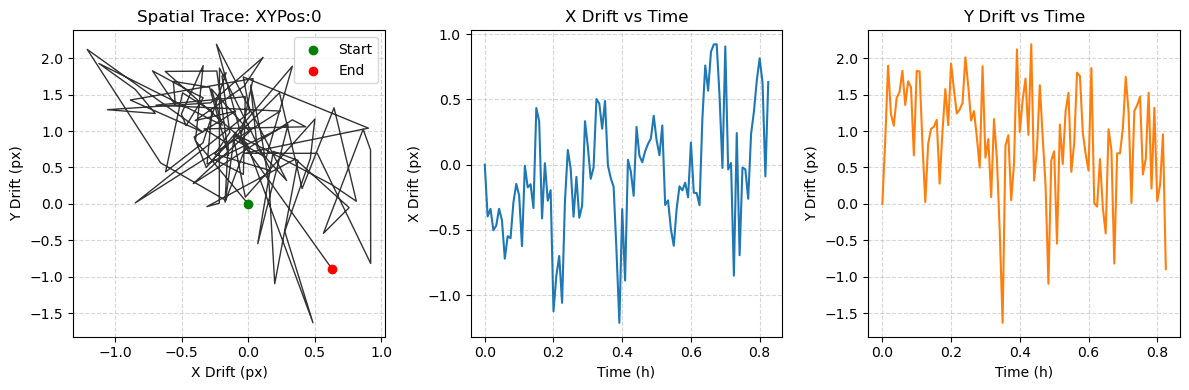

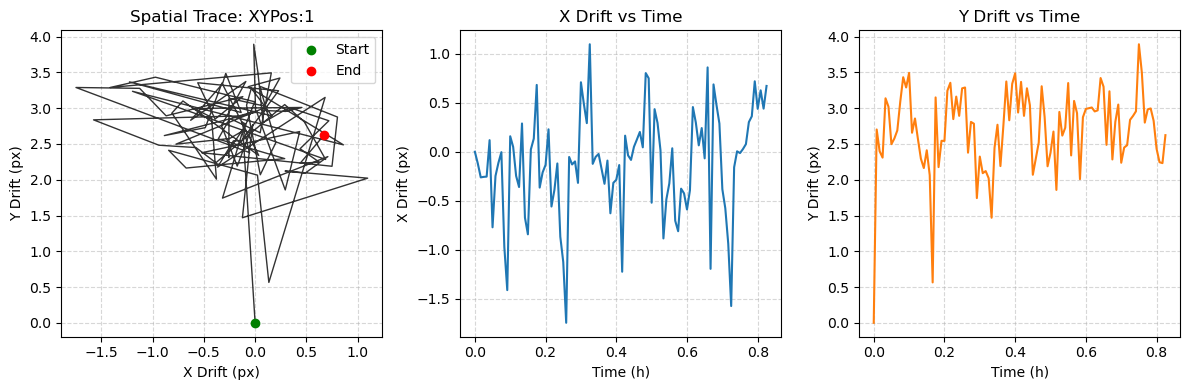

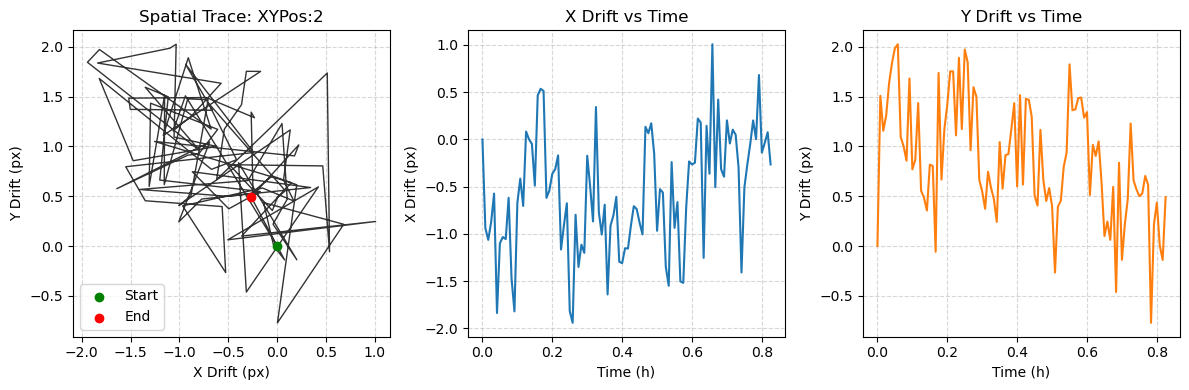

Registration saved to /data/scientific_data/20260109_SB7_exit_snake.pymmm.zarr


In [21]:
if store.has_registration():
    print("Loading registration from checkpoint...")
    reg = Registrator.load(exp, store)
else:
    reg = Registrator(
        exp, store,
        registration_channel="PC",  # ← Change to your phase-contrast channel
        mode="first",
        rotation=0,               # ← Adjust rotation if needed
        roi={"y": (0, -1), "x": (0, -1)},
    )
    reg.compute_mean_images(plot=False)
    reg.compute_tmats(plot=True)  # n_jobs=-1 by default (all cores)
    reg.save()

In [22]:
# Interactive browse registered data
reg.get_stabilized_data().hvplot.image(
    x="X", y="Y", cmap="Greys_r", dynamic=True,
    rasterize=True, widget_location="top", aspect="equal"
)

BokehModel(combine_events=True, render_bundle={'docs_json': {'86b2dd5f-14ac-40b3-bc97-e39402b40f13': {'version…

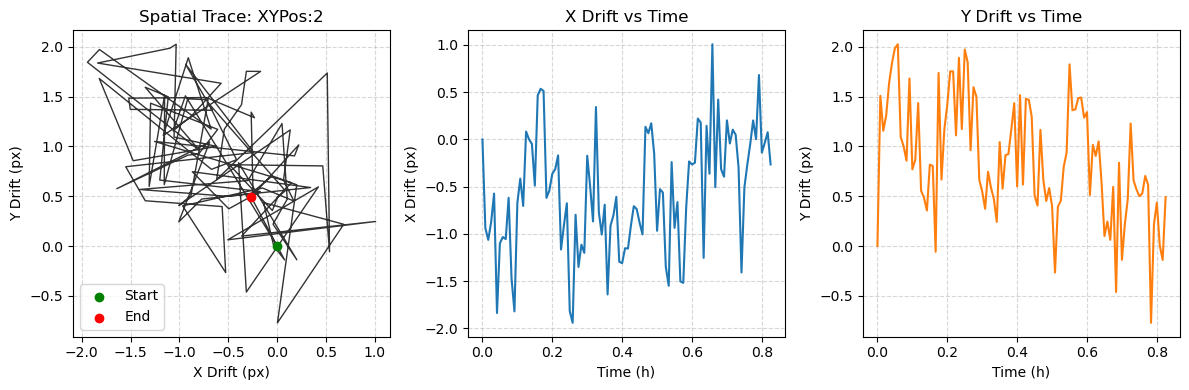

In [24]:
# Drift diagnostics for a specific FOV
reg.plot_drift(fov=2)

## 4. Lane Detection (Checkpoint 2)

Detect the feeding lane y-positions in each FOV.

Cleared 'lane_detection' from /data/scientific_data/20260109_SB7_exit_snake.pymmm.zarr
Detected lanes: XYPos:0: 1, XYPos:1: 1, XYPos:2: 1


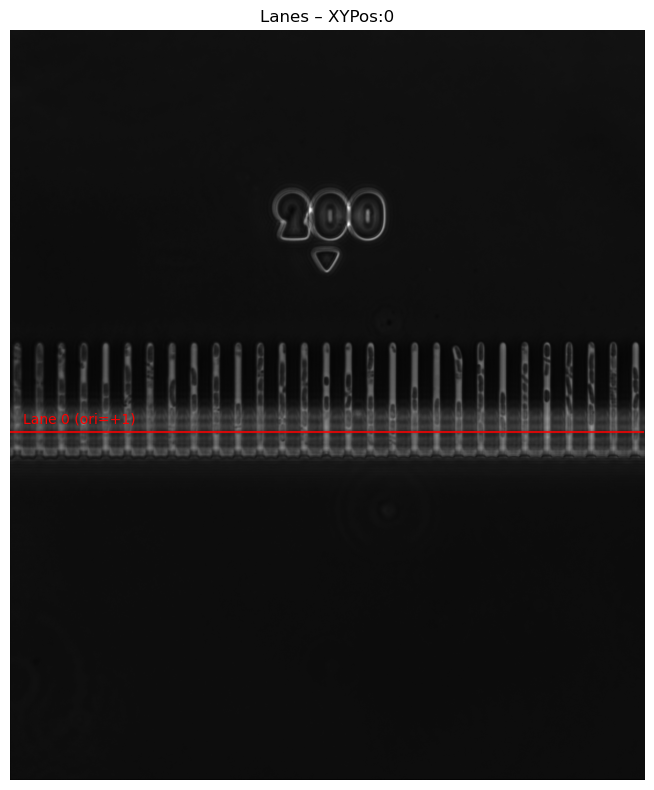

Lane detection saved to /data/scientific_data/20260109_SB7_exit_snake.pymmm.zarr


In [31]:
store.reset("lane_detection")
if store.has_lane_detection():
    print("Loading lane detection from checkpoint...")
    lane_det = LaneDetector.load(exp, reg, store)
else:
    lane_det = LaneDetector(exp, reg, store, detection_channel="PC")
    lane_det.detect_lanes(sigma=40, distance=200, height=2000, plot=True)
    lane_det.save()

In [ ]:
# Inspect another FOV
# lane_det.plot_fov(fov=1)

## 5. Trench Detection (Checkpoint 3)

Detect trench x-positions within each lane.

Cleared 'trench_detection' from /data/scientific_data/20260109_SB7_exit_snake.pymmm.zarr
Detected 83 trenches across 3 FOVs


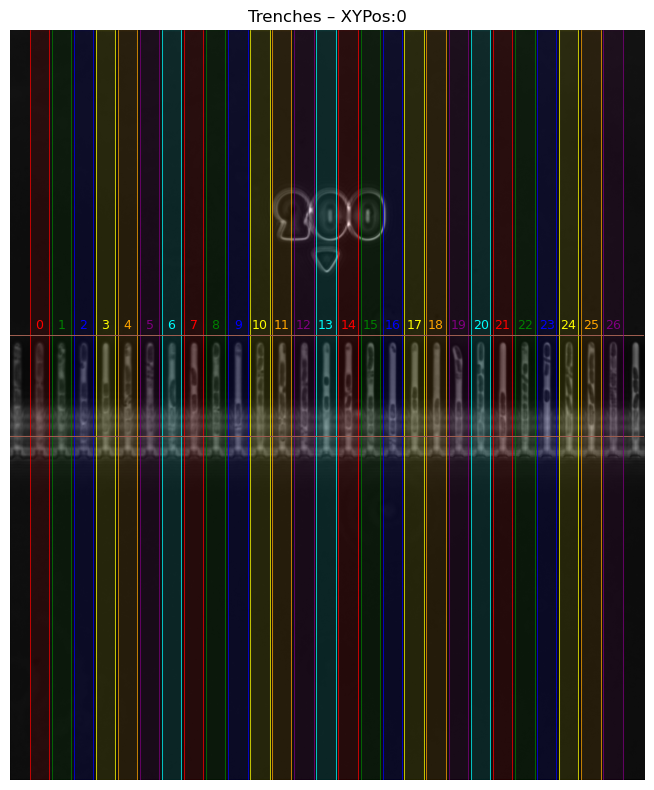

Trench detection saved to /data/scientific_data/20260109_SB7_exit_snake.pymmm.zarr


In [43]:
store.reset("trench_detection")
if store.has_trench_detection():
    print("Loading trench detection from checkpoint...")
    trench_det = TrenchDetector.load(exp, reg, lane_det, store)
else:
    trench_det = TrenchDetector(exp, reg, lane_det, store, detection_channel="PC")
    trench_det.detect_trenches(
        sigma=4, distance=10, prominence=10,
        trench_width=40, trench_length=210,
        trench_bottom_offset=-10, plot=True
    )
    # Optionally discard bad trenches:
    # trench_det.discard_trenches([20, 21, 30])
    trench_det.save()

In [47]:
# Trench table
trench_det.get_trench_table()

,trench_id,fov,lane_index,x_left,x_right,y_top,y_bottom,orientation,needs_flip
0,0,XYPos:0,0,40,80,626,836,1,False
1,1,XYPos:0,0,85,125,626,836,1,False
2,2,XYPos:0,0,131,171,626,836,1,False
3,3,XYPos:0,0,176,216,626,836,1,False
4,4,XYPos:0,0,222,262,626,836,1,False
...,...,...,...,...,...,...,...,...,...
78,78,XYPos:2,0,1085,1125,632,842,1,False
79,79,XYPos:2,0,1131,1171,632,842,1,False
80,80,XYPos:2,0,1175,1215,632,842,1,False
81,81,XYPos:2,0,1220,1260,632,842,1,False


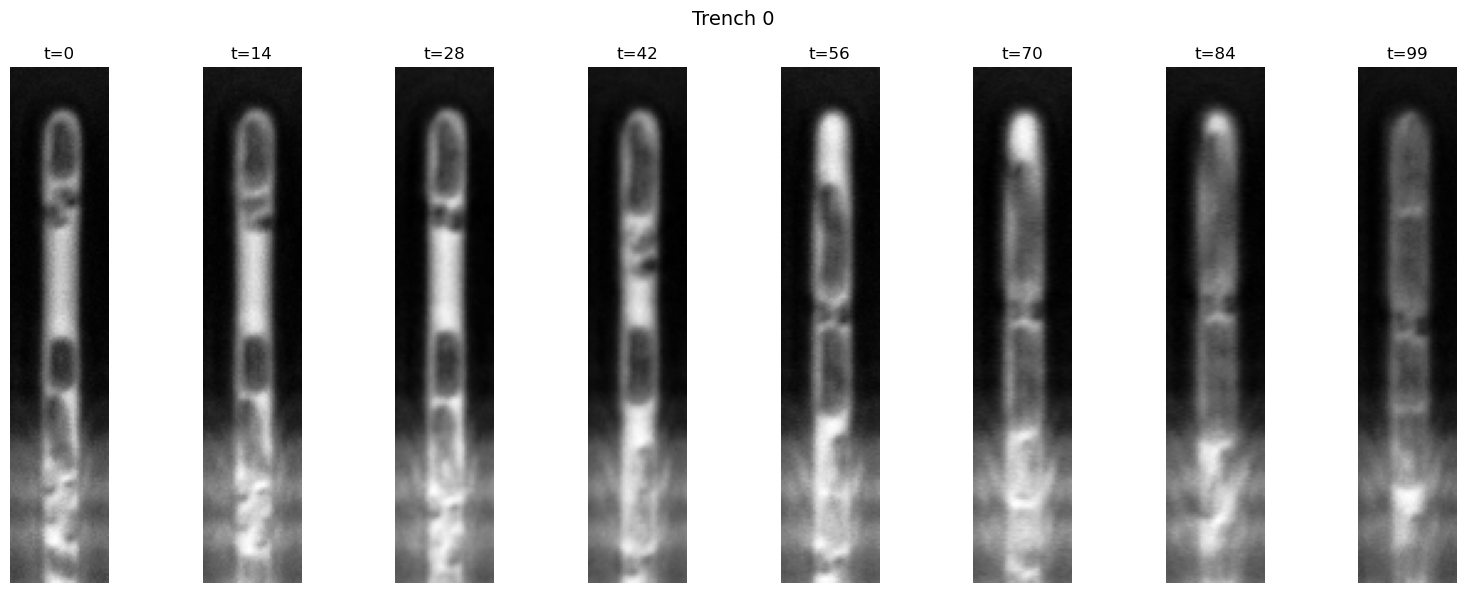

In [48]:
# Preview a single trench before full extraction
from pymmm.plotting import plot_trench_preview
preview = trench_det_extractor_preview = Extractor(exp, reg, trench_det)
single = preview.extract_single_trench(trench_id=0)
plot_trench_preview(single, trench_id=0, n_frames=8)

## 6. Extraction

Extract all trenches to a compressed zarr store.

In [49]:
extractor = Extractor(exp, reg, trench_det)
extractor.extract(compressor='zstd', clevel=9, show_progress=True)

TypeError: Expected an iterable of integers. Got (83, 100, 2, np.int64(210), np.int64(40)) instead.

## 7. Verify output

In [ ]:
import zarr

z = zarr.open(str(extractor.output_path), mode='r')
print("Shape:", z['data'].shape)
print("Chunks:", z['data'].chunks)
print("Attrs:", dict(z.attrs))